# 记忆库实验

实验基于 `core/` 代码库。每个实验运行前需启动 ollama（已配置）。

结果会缓存到 `experiment_results/` 目录，避免重复运行。

In [2]:
import json
import os
import re
import subprocess
import sys
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CORE_DIR = Path('.').resolve()
RESULT_DIR = Path('experiment_results').resolve()
RESULT_DIR.mkdir(exist_ok=True)

if str(CORE_DIR) not in sys.path:
    sys.path.insert(0, str(CORE_DIR))

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print(f'Core dir: {CORE_DIR}')
print(f'Results dir: {RESULT_DIR}')

Core dir: /home/hjd/memorystore/core
Results dir: /home/hjd/memorystore/core/experiment_results


## 辅助函数

In [3]:
def run_test(strategies: str, test_file: str, test_id: str = '',
             env: dict | None = None, tag: str = '') -> dict:
    """运行单次测试，返回结果摘要。结果缓存在 experiment_results/。"""
    safe_tag = tag or f'{strategies}_{test_file}_{test_id or "all"}'
    cache_path = RESULT_DIR / f'{safe_tag}.json'

    if cache_path.exists():
        print(f'[缓存] 加载 {cache_path.name}')
        return json.loads(cache_path.read_text(encoding='utf-8'))

    cmd = [
        sys.executable, 'main.py',
        '--test-file', test_file,
        '--strategies', strategies,
        '--no-save',
    ]
    if test_id:
        cmd += ['--test-id', test_id]

    proc_env = os.environ.copy()
    proc_env['MEMORY_STRATEGIES'] = strategies
    root_dir = str(Path('.').resolve())
    old_pythonpath = proc_env.get('PYTHONPATH', '')
    proc_env['PYTHONPATH'] = f"{root_dir}{os.pathsep}{old_pythonpath}" if old_pythonpath else root_dir
    if env:
        proc_env.update(env)

    print(f'[运行] {safe_tag}')
    t0 = time.time()
    result = subprocess.run(cmd, cwd=str(CORE_DIR), env=proc_env,
                            capture_output=True, text=True, timeout=3600)
    elapsed = time.time() - t0
    if result.returncode != 0:
        print(f'[错误] {safe_tag} | RC={result.returncode} | {elapsed:.1f}s')
        if result.stderr:
            print(result.stderr[:1500])
        return {
            'tag': tag, 'strategies': strategies, 'test_file': test_file,
            'test_id': test_id, 'env': env or {}, 'elapsed': elapsed,
            'records': [], 'total_passed': 0, 'total_evals': 0,
            'overall_score': 0.0, 'error': True,
            'returncode': result.returncode, 'stderr': result.stderr,
            'stdout': result.stdout,
        }

    print(f'[完成] {safe_tag} | RC=0 | {elapsed:.1f}s')

    # 解析日志: 2024-... | INFO | [id] type | passed/total | score=...
    records = []
    score_re = re.compile(r'\[(.+?)\]\s+(?:consistency|forgetting)\s*\|\s*(\d+)/(\d+)\s*\|\s*score=([\d.]+)')
    for line in result.stdout.split('\n'):
        m = score_re.search(line)
        if m:
            records.append({
                'test_id': m.group(1),
                'passed': int(m.group(2)),
                'total': int(m.group(3)),
                'score': float(m.group(4)),
            })

    total_p = sum(r['passed'] for r in records)
    total_t = sum(r['total'] for r in records)
    summary = {
        'tag': tag,
        'strategies': strategies,
        'test_file': test_file,
        'test_id': test_id,
        'env': env or {},
        'elapsed': elapsed,
        'records': records,
        'total_passed': total_p,
        'total_evals': total_t,
        'overall_score': total_p / total_t if total_t else 0.0,
        'stdout': result.stdout,
        'stderr': result.stderr,
    }
    cache_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
    return summary


def run_batch(configs: list[dict]) -> list[dict]:
    """并行运行多个测试配置，返回与 configs 同序的结果列表。"""
    if len(configs) <= 1:
        cfg = configs[0].copy() if configs else {}
        tag = cfg.pop('tag', '')
        return [run_test(tag=tag, **cfg)] if cfg else []

    results: dict[int, dict] = {}
    with ThreadPoolExecutor(max_workers=min(len(configs), 4)) as pool:
        futures: dict = {}
        for i, cfg in enumerate(configs):
            cfg_copy = cfg.copy()
            tag = cfg_copy.pop('tag', '')
            futures[pool.submit(run_test, tag=tag, **cfg_copy)] = i

        for fut in as_completed(futures):
            idx = futures[fut]
            try:
                results[idx] = fut.result()
            except Exception as e:
                print(f'[错误] 配置 #{idx} 运行失败: {e}')
                results[idx] = {}

    return [results[i] for i in range(len(configs))]


def extract_score(summary: dict) -> float:
    return summary.get('overall_score', 0.0)


def extract_passed_total(summary: dict) -> tuple[int, int]:
    return summary.get('total_passed', 0), summary.get('total_evals', 0)

---
## 实验 1：上下文窗口大小 vs 一致性

使用 ShortMem 策略，指定具体窗口容量（tokens），
测试 `consistency_test_7`，观察上下文窗口大小对一致性的影响。

- 通过 `SECOND_WATER_LEVEL = 窗口容量 / MAX_CONTEXT_WINDOW(8000)` 换算水位线
- 值越大 → 上下文窗口越大 → 保留的历史越多

In [8]:
from src.memory.constant import MAX_CONTEXT_WINDOW

WINDOW_SIZES = [100, 500, 1000, 1500, 2000, 2500, 3000]
WATER_LEVELS = [ws / MAX_CONTEXT_WINDOW for ws in WINDOW_SIZES]

exp1_configs = [
    {
        'tag': f'exp1_w{ws}',
        'strategies': 'ShortMem',
        'test_file': 'conversation_tests_consistency.json',
        'test_id': 'consistency_test_7',
        'env': {'SHORT_MEM_SECOND_WATER_LEVEL': str(wl)},
    }
    for ws, wl in zip(WINDOW_SIZES, WATER_LEVELS)
]

exp1_summaries = run_batch(exp1_configs)
exp1_results = []
for ws, summary in zip(WINDOW_SIZES, exp1_summaries):
    p, t = extract_passed_total(summary)
    exp1_results.append({
        'context_window': ws,
        'score': extract_score(summary),
        'passed': p,
        'total': t,
    })

[缓存] 加载 exp1_w100.json[缓存] 加载 exp1_w500.json
[缓存] 加载 exp1_w1000.json

[缓存] 加载 exp1_w1500.json
[缓存] 加载 exp1_w2000.json
[缓存] 加载 exp1_w2500.json
[缓存] 加载 exp1_w3000.json


/tmp/ipykernel_19609/1914067930.py:15: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/1914067930.py:15: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/1914067930.py:15: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/1914067930.py:15: UserWarning: Glyph 31383 (\N{CJK UNIFIED IDEOGRAPH-7A97}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/1914067930.py:15: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/1914067930.py:15: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/1914067930.py:15: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from current font.
  plt.

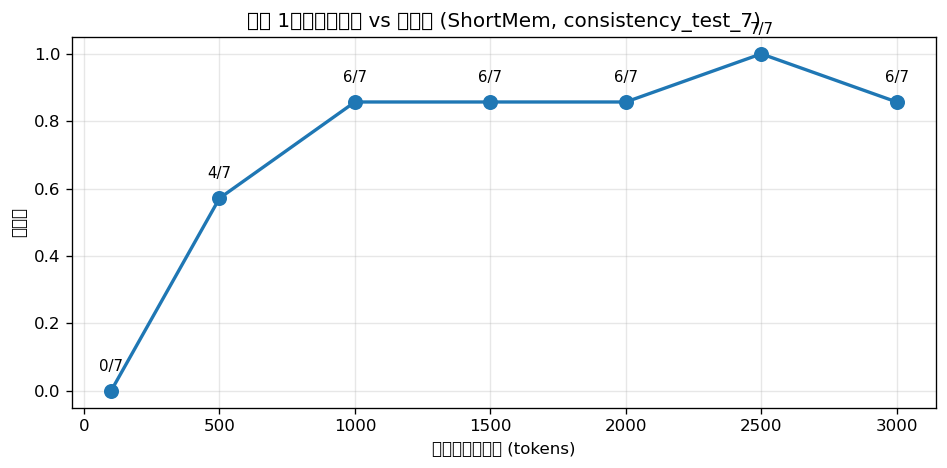

  window=  100  score=0.0000  (0/7)
  window=  500  score=0.5714  (4/7)
  window= 1000  score=0.8571  (6/7)
  window= 1500  score=0.8571  (6/7)
  window= 2000  score=0.8571  (6/7)
  window= 2500  score=1.0000  (7/7)
  window= 3000  score=0.8571  (6/7)


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
xs = [r['context_window'] for r in exp1_results]
ys = [r['score'] for r in exp1_results]
labels = [f'{r["passed"]}/{r["total"]}' for r in exp1_results]

ax.plot(xs, ys, 'o-', linewidth=2, markersize=8)
for x, y, label in zip(xs, ys, labels):
    ax.annotate(label, (x, y), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9)
ax.set_xlabel('上下文窗口大小 (tokens)')
ax.set_ylabel('准确率')
ax.set_title('实验 1：上下文窗口 vs 一致性 (ShortMem, consistency_test_7)')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'exp1_context_window_vs_consistency.png', dpi=150)
plt.show()
print('\n'.join([
    f'  window={r["context_window"]:5d}  score={r["score"]:.4f}  ({r["passed"]}/{r["total"]})'
    for r in exp1_results
]))

---
## 实验 2：LongMem vs ShortMem — 遗忘测试

固定上下文窗口（`SECOND_WATER_LEVEL=0.5`），对比 LongMem 和 ShortMem
在 `conversation_tests_forgetting.json` 上的表现。

LongMem 使用 ChromaDB 后端（默认）。

In [12]:
exp2_configs = [
    {'tag': f'exp2_{s}', 'strategies': s, 'test_file': 'conversation_tests_forgetting.json'}
    for s in ['ShortMem', 'LongMem']
]

exp2_summaries = run_batch(exp2_configs)
exp2_results = []
for s, summary in zip(['ShortMem', 'LongMem'], exp2_summaries):
    p, t = extract_passed_total(summary)
    exp2_results.append({
        'strategy': s,
        'score': extract_score(summary),
        'passed': p,
        'total': t,
    })

[缓存] 加载 exp2_ShortMem.json
[缓存] 加载 exp2_LongMem.json


/tmp/ipykernel_19609/574698746.py:13: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/574698746.py:13: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/574698746.py:13: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/574698746.py:13: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/574698746.py:13: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/574698746.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/574698746.py:13: UserWarning: Glyph 36951 (\N{CJK UNIFIED IDEOGRAPH-9057}) missing from current font.
  plt.tight_layout()
/tm

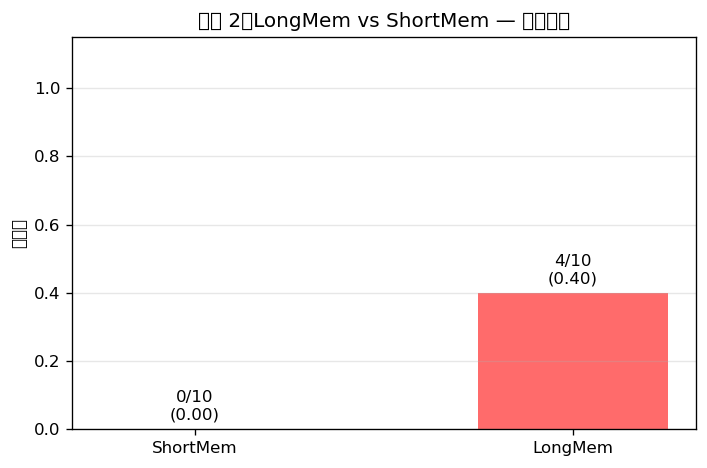

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
names = [r['strategy'] for r in exp2_results]
scores = [r['score'] for r in exp2_results]
bars = ax.bar(names, scores, color=['#4ECDC4', '#FF6B6B'], width=0.5)
for bar, r in zip(bars, exp2_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{r["passed"]}/{r["total"]}\n({r["score"]:.2f})',
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('准确率')
ax.set_title('实验 2：LongMem vs ShortMem — 遗忘测试')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'exp2_longmem_vs_shortmem_forgetting.png', dpi=150)
plt.show()

---
## 实验 3：不同向量库与嵌入方式的准确率对比

固定使用 LongMem 策略，对比：
1. ChromaDB（默认）
2. HNSW + BGE-M3（`BAAI/bge-m3`）
3. HNSW + bge-large-zh（`BAAI/bge-large-zh-v1.5`）
4. HNSW + sentence-transformers（`all-MiniLM-L6-v2`）

测试文件：`conversation_tests_forgetting.json`

In [5]:
BACKENDS = [
    {'name': 'ChromaDB', 'env': {'LONG_MEM_BACKEND': 'chromadb'}},
    {'name': 'HNSW+BGE-M3', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-m3', 'HNSW_EMBEDDING_DEVICE': 'cpu'}},
    {'name': 'HNSW+bge-large-zh', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'bge-large-zh', 'HNSW_EMBEDDING_DEVICE': 'cpu'}},
    {'name': 'HNSW+sentence-transformers', 'env': {'LONG_MEM_BACKEND': 'hnsw', 'HNSW_EMBEDDING': 'sentence-transformers', 'HNSW_EMBEDDING_DEVICE': 'cpu'}},
]

exp3_configs = [
    {
        'tag': f'exp3_{b["name"]}',
        'strategies': 'LongMem',
        'test_file': 'conversation_tests_forgetting.json',
        'env': b['env'],
    }
    for b in BACKENDS
]

exp3_summaries = run_batch(exp3_configs)
exp3_results = []
for b, summary in zip(BACKENDS, exp3_summaries):
    p, t = extract_passed_total(summary)
    exp3_results.append({
        'name': b['name'],
        'score': extract_score(summary),
        'passed': p,
        'total': t,
    })

[缓存] 加载 exp3_ChromaDB.json
[缓存] 加载 exp3_HNSW+BGE-M3.json
[缓存] 加载 exp3_HNSW+bge-large-zh.json
[缓存] 加载 exp3_HNSW+sentence-transformers.json


/tmp/ipykernel_19609/681540732.py:14: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/681540732.py:14: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/681540732.py:14: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/681540732.py:14: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/681540732.py:14: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/681540732.py:14: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19609/681540732.py:14: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  plt.tight_layout()
/tm

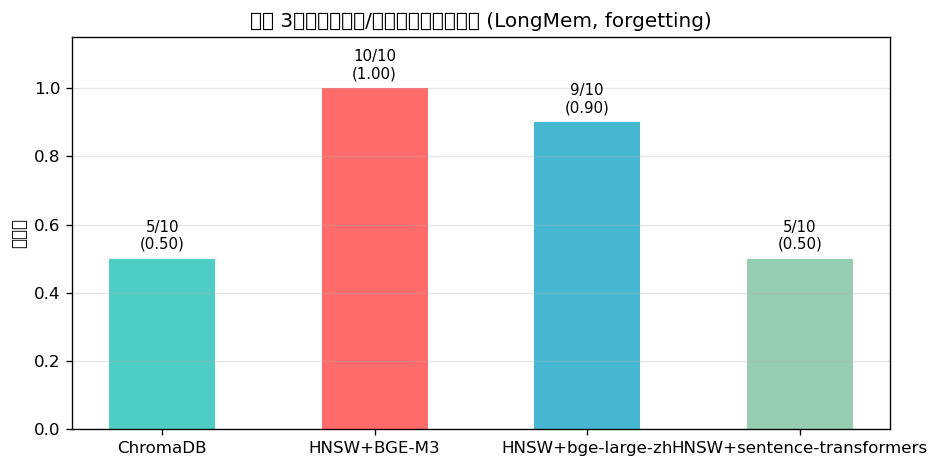

  ChromaDB                       score=0.5000  (5/10)
  HNSW+BGE-M3                    score=1.0000  (10/10)
  HNSW+bge-large-zh              score=0.9000  (9/10)
  HNSW+sentence-transformers     score=0.5000  (5/10)


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
names = [r['name'] for r in exp3_results]
scores = [r['score'] for r in exp3_results]
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4']
bars = ax.bar(names, scores, color=colors, width=0.5)
for bar, r in zip(bars, exp3_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{r["passed"]}/{r["total"]}\n({r["score"]:.2f})',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('准确率')
ax.set_title('实验 3：不同向量库/嵌入方式准确率对比 (LongMem, forgetting)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'exp3_backend_comparison.png', dpi=150)
plt.show()
print('\n'.join([f'  {r["name"]:30s} score={r["score"]:.4f}  ({r["passed"]}/{r["total"]})' for r in exp3_results]))

---
## 汇总对比表

In [7]:
print('=' * 70)
print('实验汇总')
print('=' * 70)
print()
print('--- 实验 1：上下文窗口 vs 一致性 ---')
for r in exp1_results:
    print(f'  window={r["context_window"]:5d}  {r["passed"]:2d}/{r["total"]:1d} = {r["score"]:.4f}')
print()
print('--- 实验 2：LongMem vs ShortMem (遗忘测试) ---')
for r in exp2_results:
    print(f'  {r["strategy"]:20s}  {r["passed"]:2d}/{r["total"]:2d} = {r["score"]:.4f}')
print()
print('--- 实验 3：向量库/嵌入方式对比 ---')
for r in exp3_results:
    print(f'  {r["name"]:30s}  {r["passed"]:2d}/{r["total"]:2d} = {r["score"]:.4f}')
print()

实验汇总

--- 实验 1：上下文窗口 vs 一致性 ---


NameError: name 'exp1_results' is not defined